<h1 style="color:#FFFFFF; background-color:#4C1D95; text-align:center; font-weight:bold; padding:17px 10px; border-radius:8px; margin-bottom:6px;">Week 6 — Day 3: Backpropagation, Gradient Descent &amp; Optimizers</h1>
<p style="color:#FFFFFF; background-color:gray; text-align:center; font-weight:bold; font-style:italic; padding:7px 10px; border-radius:6px; margin-top:0; font-size:15px;">Cardiac Patient Monitoring System — How Loss Becomes Learning</p>

<div style="border-left:5px solid #7C3AED; background-color:rgba(124, 58, 237, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Accessibility:</b> This notebook does not rely on color alone. Important meanings are also communicated with labels, line styles, table text, and explicit annotations. Callout backgrounds use transparency so text remains readable in both light and dark notebook themes.
</div>

<a id="toc"></a>
<h2 style="color:#FDE68A; background-color:#4C1D95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>
<div style="border:1px solid rgba(127,127,127,0.55); padding:15px 25px; border-radius:6px; color:inherit;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup &amp; Reproducibility</a></li>
<li><a href="#section1">1. The Training Loop in One Picture</a></li>
<li><a href="#section2">2. Gradient Descent</a></li>
<li><a href="#section3">3. The Learning Rate</a></li>
<li><a href="#section4">4. Backpropagation &amp; the Chain Rule</a></li>
<li><a href="#section5">5. Optimizers, Epochs &amp; Batches</a></li>
<li><a href="#section6">6. Common Mistakes to Avoid</a></li>
<li><a href="#section7">7. Quick Reference</a></li>
<li><a href="#section8">8. Hands-On Lab — Understanding Training + Mentor Review</a></li>
<li><a href="#section9">9. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section10">10. Daily Stand-up &amp; Mentor Review Status</a></li>
<li><a href="#section11">11. Summary — What I Learned Today</a></li>
</ol>
</div>

<a id="section0"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">0. Setup &amp; Reproducibility</h2>

<div style="border-left:5px solid #7C3AED; background-color:rgba(124, 58, 237, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Note:</b> Day 2 established the forward pass and binary cross-entropy loss for the Cardiac Patient Monitoring System. Day 3 explains how that loss is propagated backward to compute gradients and how an optimizer uses those gradients to update weights.
</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

print("NumPy version      :", np.__version__)
print("Random seed        :", SEED)
print("Project            : Cardiac Patient Monitoring System")

NumPy version      : 2.3.5
Random seed        : 42
Project            : Cardiac Patient Monitoring System


<a id="section1"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">1. The Training Loop in One Picture</h2>

Training a neural network is a repeated four-step loop. Each step has one job, and the same loop runs over many batches and epochs:

<div style="border:1px solid rgba(127,127,127,0.55); border-radius:7px; overflow:hidden; margin:10px 0;">
<table style="width:100%; border-collapse:collapse; color:inherit;">
<tr style="background-color:#4C1D95; color:#FFFFFF;"><th style="padding:9px; text-align:left;">Step</th><th style="padding:9px; text-align:left;">What Happens</th><th style="padding:9px; text-align:left;">Why It Matters</th></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>1. Forward pass</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Inputs flow through weighted sums and activations.</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Produces a prediction.</td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>2. Loss</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Prediction is compared with the true label.</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Quantifies how wrong the model is.</td></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>3. Backpropagation</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Gradients are computed from output back toward earlier layers.</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Measures how each parameter affected the loss.</td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>4. Update</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Optimizer moves parameters opposite the gradient.</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Aims to reduce the next loss.</td></tr>
</table>
</div>

<div style="border-left:5px solid #0E7490; background-color:rgba(14, 116, 144, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Goal:</b> Remember the loop as <b>forward → loss → backprop → update</b>. Day 2 covered the first two steps; today focuses on the last two.
</div>

<a id="section2"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">2. Gradient Descent</h2>

A gradient tells us how the loss changes when a parameter changes. Gradient descent updates each parameter in the <b>opposite</b> direction of its gradient because that is the local downhill direction.

<div style="text-align:center; border:1px solid rgba(127,127,127,0.50); padding:12px; border-radius:7px; margin:12px 0; color:inherit;">
<span style="font-size:18px;"><b>parameter<sub>new</sub> = parameter<sub>old</sub> − learning_rate × gradient</b></span>
</div>

In [ ]:
# One simple gradient-descent update
weight = 2.0
gradient = 0.8
learning_rate = 0.1

updated_weight = weight - learning_rate * gradient

print(f"Old weight     : {weight:.3f}")
print(f"Gradient       : {gradient:.3f}")
print(f"Learning rate  : {learning_rate:.3f}")
print(f"Updated weight : {updated_weight:.3f}")

Old weight     : 2.000
Gradient       : 0.800
Learning rate  : 0.100
Updated weight : 1.920


<div style="border-left:5px solid #a99485; background-color:rgba(180, 83, 9, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Important:</b> The gradient is not the update itself. The optimizer combines the gradient with a learning rate and possibly other state (such as momentum or adaptive step sizes) to decide the actual parameter change.
</div>

<a id="section3"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">3. The Learning Rate</h2>

The learning rate controls the size of each update. Too small can make training painfully slow; too large can overshoot useful regions and make the loss oscillate or diverge.

<div style="border:1px solid rgba(127,127,127,0.55); border-radius:7px; overflow:hidden; margin:10px 0;">
<table style="width:100%; border-collapse:collapse; color:inherit;">
<tr style="background-color:#4C1D95; color:#FFFFFF;"><th style="padding:9px; text-align:left;">Learning Rate</th><th style="padding:9px; text-align:left;">Typical Behavior</th></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Too low</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Loss decreases very slowly; training may appear stuck.</td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Appropriate</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Loss decreases steadily and efficiently.</td></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Too high</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Loss may jump, oscillate, or diverge.</td></tr>
</table>
</div>

<div style="border-left:5px solid #a99485; background-color:rgba(194, 65, 12, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Tip:</b> Learning-rate values are optimizer- and problem-dependent. The toy NumPy experiment later uses plain full-batch gradient descent. On Day 4, when using Adam in Keras, a starting learning rate around <code>0.001</code> is a common default.
</div>

<a id="section4"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">4. Backpropagation &amp; the Chain Rule</h2>

Backpropagation is the efficient algorithm used to compute the gradient of the loss with respect to every trainable weight and bias. It starts at the loss and works backward through the computation graph.

<div style="border-left:5px solid #7C3AED; background-color:rgba(124, 58, 237, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Explanation:</b> The <b>chain rule</b> is needed because an early weight does not affect the loss directly. It affects a hidden value, which affects a later value, which affects the output, which affects the loss. Backpropagation multiplies these local effects along the path so the model can determine how much each earlier parameter contributed to the final error.
</div>

<div style="text-align:center; border:1px solid rgba(127,127,127,0.50); padding:12px; border-radius:7px; margin:12px 0; color:inherit; line-height:1.8; background:white">
<b style="color:black"> Loss ← Output activation ← Output weights ← Hidden activation ← Hidden weights</b>
<br><span style="font-size:13px; color:black">Gradients flow backward while predictions flow forward.</span>
</div>

<div style="border-left:5px solid #a99485; background-color:rgba(180, 83, 9, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Important:</b> Backpropagation does <b>not</b> randomly guess better weights. It computes derivatives. The optimizer then uses those derivatives to update the parameters.
</div>

<a id="section5"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">5. Optimizers, Epochs &amp; Batches</h2>

<div style="border:1px solid rgba(127,127,127,0.55); border-radius:7px; overflow:hidden; margin:10px 0;">
<table style="width:100%; border-collapse:collapse; color:inherit;">
<tr style="background-color:#4C1D95; color:#FFFFFF;"><th style="padding:9px; text-align:left;">Term</th><th style="padding:9px; text-align:left;">Meaning</th></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Optimizer</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">The algorithm that applies parameter updates; Adam is a strong default.</td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Epoch</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">One full pass through the training dataset.</td></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Batch</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">A subset of data processed before an update.</td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>SGD</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Uses gradients directly, optionally with momentum.</td></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Adam</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Adapts step sizes per parameter using running gradient statistics.</td></tr>
</table>
</div>

<div style="border-left:5px solid #a99485; background-color:rgba(194, 65, 12, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Tip:</b> A batch size such as 32 is common, but there is no universal best value. The right setting depends on the dataset, hardware, and training behavior.
</div>

<a id="section6"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">6. Common Mistakes to Avoid</h2>

<div style="border-left:5px solid #a99485; background-color:rgba(180, 83, 9, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Important:</b> <ul style="margin-bottom:0;">
<li><b>Updating in the gradient direction</b> instead of the opposite direction.</li>
<li><b>Assuming a larger learning rate always trains faster</b> — it can destabilize training.</li>
<li><b>Confusing backpropagation with the optimizer</b> — backprop computes gradients; the optimizer applies updates.</li>
<li><b>Judging training from one epoch</b> — inspect the loss trend across epochs.</li>
<li><b>Comparing learning rates on different random initializations</b> — keep the seed and data fixed for a fair comparison.</li>
<li><b>Using the test set to choose hyperparameters</b> — tuning belongs on training/validation data; the test set is for final evaluation.</li>
</ul>
</div>

<a id="section7"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">7. Quick Reference</h2>

<div style="border:1px solid rgba(127,127,127,0.55); border-radius:7px; overflow:hidden; margin:10px 0;">
<table style="width:100%; border-collapse:collapse; color:inherit;">
<tr style="background-color:#4C1D95; color:#FFFFFF;"><th style="padding:9px; text-align:left;">Concept</th><th style="padding:9px; text-align:left;">One-Line Reminder</th></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Training loop</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><code>forward → loss → backprop → update</code></td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Gradient descent</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><code>parameter -= learning_rate * gradient</code></td></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Backpropagation</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Efficiently computes gradients from the loss backward through the network.</td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Chain rule</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Combines local derivatives across dependent operations.</td></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Learning rate</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Controls update size.</td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Epoch</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">One full pass through the training set.</td></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Batch</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Subset processed before one update.</td></tr>
<tr style="background-color:rgba(124,58,237,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Adam</td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Strong default optimizer for many neural-network tasks.</td></tr>
</table>
</div>

<a id="section8"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">8. Hands-On Lab — Understanding Training + Mentor Review</h2>

<div style="border-left:5px solid #0E7490; background-color:rgba(14, 116, 144, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Goal:</b> Describe the training loop, experiment with three learning rates on the <b>same</b> tiny network, explain backpropagation and the chain rule, and prepare the project notebook for the mid-sprint mentor review.
</div>

<h3 style="color:#FFFFFF; background-color:#312E81; display:inline-block; font-weight:bold; padding:5px 11px; border-radius:6px; margin-top:18px;">Step 1 — Describe the four-step training loop</h3>

For the Cardiac Patient Monitoring System, the same loop will be used when the Keras model is trained on Day 4: <b>forward pass → binary cross-entropy loss → backpropagation → optimizer update</b>. This Day 3 lab uses a tiny self-contained NumPy network only to make the mechanics visible.

<h3 style="color:#FFFFFF; background-color:#312E81; display:inline-block; font-weight:bold; padding:5px 11px; border-radius:6px; margin-top:18px;">Step 2 — Compare three learning rates on the same tiny network</h3>

<div style="border-left:5px solid #7C3AED; background-color:rgba(124, 58, 237, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Note:</b> The data below are synthetic and are used only to demonstrate optimization behavior. They are <b>not</b> patient records and this cell does not train the project's clinical model.
</div>

In [ ]:
# Synthetic binary-classification data for a transparent training-mechanics demo
rng = np.random.default_rng(SEED)
X_demo = rng.normal(size=(240, 4))
score = (
    1.2 * X_demo[:, 0]
    - 1.0 * X_demo[:, 1]
    + 0.8 * X_demo[:, 2]
    + 0.5 * X_demo[:, 3]
    + 0.2 * rng.normal(size=240)
)
y_demo = (score > 0).astype(float).reshape(-1, 1)

print("Demo X shape:", X_demo.shape)
print("Demo y shape:", y_demo.shape)
print("Positive class proportion:", round(float(y_demo.mean()), 3))

Demo X shape: (240, 4)
Demo y shape: (240, 1)
Positive class proportion: 0.454


In [ ]:
def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def train_tiny_network(X, y, learning_rate, epochs=120, seed=7):
    # Same initialization for every learning-rate run -> fair comparison
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 0.3, size=(X.shape[1], 6))
    b1 = np.zeros((1, 6))
    W2 = rng.normal(0, 0.3, size=(6, 1))
    b2 = np.zeros((1, 1))

    losses = []

    for _ in range(epochs):
        # 1) Forward pass
        z1 = X @ W1 + b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ W2 + b2
        y_pred = sigmoid(z2)

        # 2) Loss
        loss = binary_cross_entropy(y, y_pred)
        losses.append(loss)

        # 3) Backpropagation
        n = len(X)
        dz2 = (y_pred - y) / n
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ W2.T
        dz1 = da1 * (z1 > 0)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # 4) Gradient-descent update
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    return np.asarray(losses)

learning_rates = {
    "Too low (0.0005)": 0.0005,
    "Appropriate for this toy run (1.0)": 1.0,
    "Too high (50.0)": 50.0,
}

loss_history = {
    label: train_tiny_network(X_demo, y_demo, lr)
    for label, lr in learning_rates.items()
}

for label, losses in loss_history.items():
    print(f"{label:<37} initial={losses[0]:.4f}  final={losses[-1]:.4f}  best={losses.min():.4f}")

Too low (0.0005)                      initial=0.6529  final=0.6504  best=0.6504
Appropriate for this toy run (1.0)    initial=0.6529  final=0.0728  best=0.0728
Too high (50.0)                       initial=0.6529  final=1.6021  best=0.6529


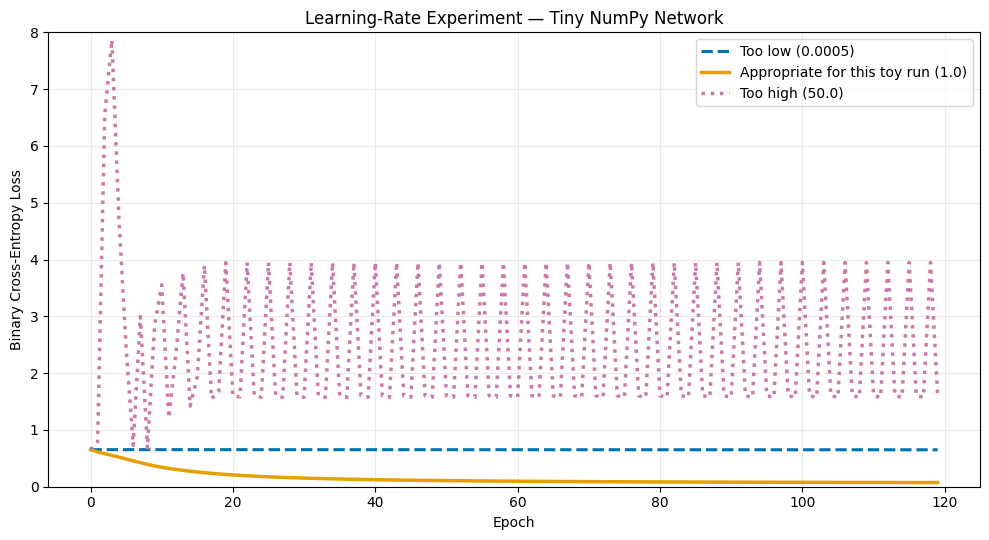

In [ ]:
# Colorblind-friendly palette + different line styles so color is never the only cue
plot_styles = {
    "Too low (0.0005)": {"color": "#0072B2", "linestyle": "--", "linewidth": 2.2},
    "Appropriate for this toy run (1.0)": {"color": "#E69F00", "linestyle": "-", "linewidth": 2.5},
    "Too high (50.0)": {"color": "#CC79A7", "linestyle": ":", "linewidth": 2.5},
}

plt.figure(figsize=(10, 5.5))
for label, losses in loss_history.items():
    plt.plot(losses, label=label, **plot_styles[label])

plt.title("Learning-Rate Experiment — Tiny NumPy Network")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.ylim(0, min(8, max(v.max() for v in loss_history.values()) * 1.05))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

<div style="border-left:5px solid #a99485; background-color:rgba(194, 65, 12, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Interpretation:</b> The very small rate barely changes the loss. The middle rate learns quickly on this toy full-batch problem. The very large rate overshoots and becomes unstable. These exact numeric rates should <b>not</b> be copied into Day 4 Adam training; the lesson is the behavior, not the absolute values.
</div>

<h3 style="color:#FFFFFF; background-color:#312E81; display:inline-block; font-weight:bold; padding:5px 11px; border-radius:6px; margin-top:18px;">Step 3 — Explain backpropagation and the chain rule in my own words</h3>

Backpropagation computes how much every weight and bias contributed to the current loss. It begins from the loss at the output and moves backward through each operation. The chain rule is required because early parameters influence the loss through several intermediate values. By multiplying the local derivatives along those dependencies, the network gets a gradient for every parameter without recomputing each effect from scratch.

<h3 style="color:#FFFFFF; background-color:#312E81; display:inline-block; font-weight:bold; padding:5px 11px; border-radius:6px; margin-top:18px;">Step 4 — Prepare the mid-sprint Mentor Code & Notebook Review</h3>

<div style="border:1px solid rgba(127,127,127,0.55); padding:13px 16px; border-radius:7px; color:inherit; line-height:1.8;">
<b>Suggested feature branch:</b> <code>feature/week6-day3-training-mechanics</code><br>
<b>Suggested commit:</b> <code>Finish Day 3 in week 6: add training mechanics and learning-rate experiments</code><br>
<b>Pull request:</b> Open against <code>main</code> for mentor review.<br>
<b>Mentor review status:</b> Pending until the real PR is reviewed.<br>
<b>Feedback addressed:</b> Pending until comments are received.
</div>

<div style="border-left:5px solid #a99485; background-color:rgba(180, 83, 9, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Important:</b> The notebook documents the required Git workflow but does not claim that a real pull request or mentor approval already exists. Complete those actions in the actual GitHub repository.
</div>

<a id="section9"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">9. Best Practices &amp; Reproducibility</h2>

<div style="border-left:5px solid #a99485; background-color:rgba(180, 83, 9, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Important:</b> <ul style="margin-bottom:0;">
<li>Keep the random seed fixed when comparing learning rates.</li>
<li>Change one training variable at a time so the comparison is interpretable.</li>
<li>Use stable implementations for sigmoid and cross-entropy to avoid numerical overflow or <code>log(0)</code>.</li>
<li>Use training/validation behavior for tuning; keep the final test set untouched until evaluation.</li>
<li>Plot the loss curve rather than trusting only the final number.</li>
<li>Record optimizer, learning rate, batch size, epochs, and seed for every serious experiment.</li>
</ul>
</div>

<a id="section10"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">10. Daily Stand-up &amp; Mentor Review Status</h2>

<div style="border:1px solid rgba(127,127,127,0.55); border-radius:7px; overflow:hidden; margin:10px 0;">
<table style="width:100%; border-collapse:collapse; color:inherit;">
<tr style="background-color:#a99485; color:#FFFFFF;"><th style="padding:9px; text-align:left; width:24%;">Stand-up Item</th><th style="padding:9px; text-align:left;">Day 3 Update</th></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Completed</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Training loop, gradient descent, learning-rate experiment, backpropagation explanation, optimizer/epoch/batch review.</td></tr>
<tr style="background-color:rgba(194,65,12,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Next</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Day 4: build and train the project neural network in TensorFlow/Keras, then compare it to the Day 1 baseline.</td></tr>
<tr><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Blockers</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">None identified in the notebook. Add any real environment, data, or Git blocker before the stand-up.</td></tr>
<tr style="background-color:rgba(194,65,12,0.06);"><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);"><b>Mentor review</b></td><td style="padding:9px; border-top:1px solid rgba(127,127,127,0.35);">Pending — update after the real pull-request review.</td></tr>
</table>
</div>

<a id="section11"></a>
<h2 style="color:#FFFFFF; background-color:#5B21B6; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">11. Summary — What I Learned Today</h2>

<div style="border-left:5px solid #a99485; background-color:rgba(194, 65, 12, 0.11); padding:11px 15px; margin:10px 0; border-radius:5px; color:inherit;">
<b>Summary:</b> <ul style="margin-bottom:0;">
<li>Neural-network training repeats <b>forward → loss → backprop → update</b>.</li>
<li>Gradient descent moves parameters opposite their gradients to reduce loss.</li>
<li>The learning rate controls update size; too low is slow and too high can be unstable.</li>
<li>Backpropagation efficiently computes gradients through the network using the chain rule.</li>
<li>SGD and Adam are optimizers; epochs and batches describe how training data are processed.</li>
<li>The learning-rate experiment showed why loss curves are necessary for diagnosing training.</li>
<li>Day 4 will apply these mechanics in TensorFlow/Keras to the Cardiac Patient Monitoring System.</li>
</ul>
</div>